#### Model config

In [1]:
GPT_CONFIG_124M = {
"vocab_size": 50257, # Vocabulary size
"context_length": 1024, # Context length
"emb_dim": 768, # Embedding dimension
"n_heads": 12, # Number of attention heads
"n_layers": 12, # Number of layers
"drop_rate": 0.1, # Dropout rate
"qkv_bias": False # Query-Key-Value bias
}

#### Dummy exmaple of GPT model

In [2]:
from torch import nn
import torch


class DummyGPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.token_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.dropout = nn.Dropout(cfg["drop_rate"])
        self.transfomer_blocks = nn.Sequential(*[
            DummyTransformerBlock(cfg)
            for _ in range(cfg["n_layers"])
        ])

        self.final_norm = DummyLayerNormalization(cfg["context_length"])
        self.final_layer = nn.Linear(cfg["emb_dim"], cfg["vocab_size"], bias=False)
    
    def forward(self, x_in):
        batch_size, seq_len = x_in.shape
        tok_embeds = self.token_emb(x_in)
        pos_embeds = self.pos_emb(
            torch.arange(seq_len, device=x_in.device)
        )
        x = tok_embeds + pos_embeds
        x = self.final_norm(self.transfomer_blocks(self.dropout(x)))
        return self.final_layer(x)

class DummyTransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
    
    def forward(self, x):
        return x

class DummyLayerNormalization(nn.Module):
    def __init__(self, normalized_shape, eps=1e-05):
        super().__init__()
    
    def forward(self, x):
        return x

In [3]:
import tiktoken

tokenizer = tiktoken.get_encoding("gpt2")
batch = []
txt1 = "Every effort moves you"
txt2 = "Every day holds a"

batch.append(torch.tensor(tokenizer.encode(txt1)))
batch.append(torch.tensor(tokenizer.encode(txt2)))
print(batch)
batch = torch.stack(batch, dim=0)
print(batch)

[tensor([6109, 3626, 6100,  345]), tensor([6109, 1110, 6622,  257])]
tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])


In [4]:
torch.manual_seed(123)
model = DummyGPTModel(GPT_CONFIG_124M)
logits = model(batch)
print("Output shape:", logits.shape)
print(logits)

Output shape: torch.Size([2, 4, 50257])
tensor([[[-1.2034,  0.3201, -0.7130,  ..., -1.5548, -0.2390, -0.4667],
         [-0.1192,  0.4539, -0.4432,  ...,  0.2392,  1.3469,  1.2430],
         [ 0.5307,  1.6720, -0.4695,  ...,  1.1966,  0.0111,  0.5835],
         [ 0.0139,  1.6754, -0.3388,  ...,  1.1586, -0.0435, -1.0400]],

        [[-1.0908,  0.1798, -0.9484,  ..., -1.6047,  0.2439, -0.4530],
         [-0.7860,  0.5581, -0.0610,  ...,  0.4835, -0.0077,  1.6621],
         [ 0.3567,  1.2698, -0.6398,  ..., -0.0162, -0.1296,  0.3717],
         [-0.2407, -0.7349, -0.5102,  ...,  2.0057, -0.3694,  0.1814]]],
       grad_fn=<UnsafeViewBackward0>)


In [5]:
torch.manual_seed(123)
batch_example = torch.randn(2, 5)
layer = nn.Sequential(nn.Linear(5, 6), nn.ReLU())
out = layer(batch_example)
print(out)

tensor([[0.2260, 0.3470, 0.0000, 0.2216, 0.0000, 0.0000],
        [0.2133, 0.2394, 0.0000, 0.5198, 0.3297, 0.0000]],
       grad_fn=<ReluBackward0>)


In [6]:
mean = out.mean(dim=-1, keepdim=True)
var = out.var(dim=-1, keepdim=True)
print("Mean:\n", mean)
print("Variance:\n", var)

Mean:
 tensor([[0.1324],
        [0.2170]], grad_fn=<MeanBackward1>)
Variance:
 tensor([[0.0231],
        [0.0398]], grad_fn=<VarBackward0>)


### LayerNormalization

In [7]:
class LayerNormalization(nn.Module):
    def __init__(self, emb_dim, eps=1e-05):
        super().__init__()
        self.eps = eps
        self.scale = nn.Parameter(torch.ones(emb_dim))
        self.shift = nn.Parameter(torch.zeros(emb_dim))
    
    def forward(self, x):
        x_var = x.var(dim=-1, keepdim=True, unbiased=False)
        x_mean = x.mean(dim=-1, keepdim=True)
        return ((x - x_mean) / torch.sqrt(x_var + self.eps)) * self.scale + self.shift

In [8]:
ln = LayerNormalization(emb_dim=5)
out_ln = ln(batch_example)
mean = out_ln.mean(dim=-1, keepdim=True)
var = out_ln.var(dim=-1, unbiased=False, keepdim=True)
print("Mean:\n", mean)
print("Variance:\n", var)

Mean:
 tensor([[-2.9802e-08],
        [ 0.0000e+00]], grad_fn=<MeanBackward1>)
Variance:
 tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


### FFN with GELU

In [9]:
class GELU(nn.Module):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)

    def forward(self, x):
        return 0.5 * x * (1 + torch.tanh(torch.sqrt(torch.tensor(2/torch.pi)) * (x + 0.044715 * torch.pow(x, 3))))

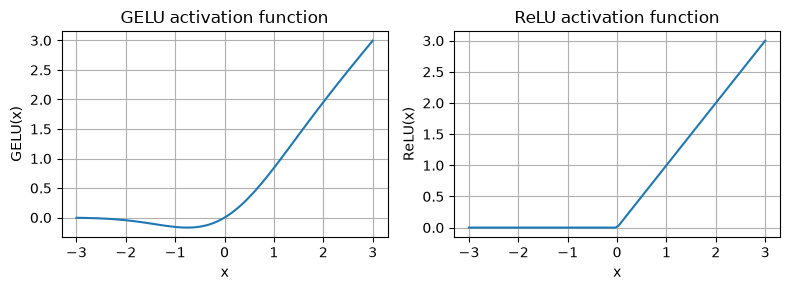

In [10]:
import matplotlib.pyplot as plt
gelu, relu = GELU(), nn.ReLU()
x = torch.linspace(-3, 3, 100)
y_gelu, y_relu = gelu(x), relu(x)
plt.figure(figsize=(8, 3))
for i, (y, label) in enumerate(zip([y_gelu, y_relu], ["GELU", "ReLU"]), 1):
    plt.subplot(1, 2, i)
    plt.plot(x, y)
    plt.title(f"{label} activation function")
    plt.xlabel("x")
    plt.ylabel(f"{label}(x)")
    plt.grid(True)
    plt.tight_layout()
plt.show()

In [11]:
class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.layers = nn.Sequential(*[
            nn.Linear(cfg["emb_dim"], 4 * cfg["emb_dim"]),
            GELU(),
            nn.Linear(4 * cfg["emb_dim"], cfg["emb_dim"])
        ])
    
    def forward(self, x):
        return self.layers(x)

In [12]:
ffn = FeedForward(GPT_CONFIG_124M)
x = torch.rand(2, 3, 768)
out = ffn(x)
print(out.shape)

torch.Size([2, 3, 768])


### Shortcut connection

In [13]:
class ExampleDeepNeuralNetwork(nn.Module):
    def __init__(self, layer_sizes, use_shortcut):
        super().__init__()
        self.use_shortcut = use_shortcut
        self.layers = nn.ModuleList([
            nn.Sequential(nn.Linear(layer_sizes[0], layer_sizes[1]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[1], layer_sizes[2]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[2], layer_sizes[3]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[3], layer_sizes[4]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[4], layer_sizes[5]), GELU()),

        ])
    
    def forward(self, x):
        for layer in self.layers:
            layer_output = layer(x)
            if self.use_shortcut and x.shape == layer_output.shape:
                x = x + layer_output
            else:
                x = layer_output
        return x

In [14]:
layer_sizes = [3, 3, 3, 3, 3, 1]
sample_input = torch.tensor([[1., 0., -1.]])
torch.manual_seed(123)
model_without_shortcut = ExampleDeepNeuralNetwork(
layer_sizes, use_shortcut=False
)

In [15]:
def print_gradients(model, x):
    output = model(x)
    target = torch.tensor([[0.]])

    loss = nn.MSELoss()
    loss = loss(output, target)

    loss.backward()

    for name, param in model.named_parameters():
        if "weight" in name:
            print(f"{name} has gradient mean of {param.grad.abs().mean().item()}")

In [16]:
print_gradients(model_without_shortcut, sample_input)

layers.0.0.weight has gradient mean of 0.00020173590746708214
layers.1.0.weight has gradient mean of 0.0001201116101583466
layers.2.0.weight has gradient mean of 0.0007152042235247791
layers.3.0.weight has gradient mean of 0.0013988739810883999
layers.4.0.weight has gradient mean of 0.00504964729771018


In [17]:
torch.manual_seed(123)
model_with_shortcut = ExampleDeepNeuralNetwork(
layer_sizes, use_shortcut=True
)
print_gradients(model_with_shortcut, sample_input)

layers.0.0.weight has gradient mean of 0.22169791162014008
layers.1.0.weight has gradient mean of 0.20694102346897125
layers.2.0.weight has gradient mean of 0.32896995544433594
layers.3.0.weight has gradient mean of 0.2665732204914093
layers.4.0.weight has gradient mean of 1.3258541822433472


### Transformer block

In [58]:
import sys
import os

sys.path.append(os.path.abspath(os.path.join('..')))

from scripts.attention import MultiHeadAttention

class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.attention = MultiHeadAttention(
            d_in=cfg["emb_dim"], 
            d_out=cfg["emb_dim"], 
            context_length=cfg["context_length"],
            dropout=cfg["drop_rate_mha"],
            num_heads=cfg["n_heads"],
            qkv_bias=cfg["qkv_bias"])
        self.ffn = FeedForward(cfg)
        self.norm1 = LayerNormalization(cfg["emb_dim"])
        self.norm2 = LayerNormalization(cfg["emb_dim"])
        self.dropout = nn.Dropout(cfg["drop_rat_shortcut"])
    
    def forward(self, x):
        shortcut = x
        x = self.norm1(x)
        x = self.attention(x)
        x = self.dropout(x)
        x = x + shortcut

        shortcut = x
        x = self.norm2(x)
        x = self.ffn(x)
        x = self.dropout(x)
        x = shortcut + x

        return x

In [19]:
torch.manual_seed(123)
x = torch.rand(2, 4, 768)
block = TransformerBlock(GPT_CONFIG_124M)
output = block(x)
print("Input shape:", x.shape)
print("Output shape:", output.shape)

Input shape: torch.Size([2, 4, 768])
Output shape: torch.Size([2, 4, 768])


### GPT-2 model

In [ ]:
class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.token_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.dropout = nn.Dropout(cfg["drop_rate_embedding"])
        self.transformer_blocks = nn.Sequential(*[
            TransformerBlock(cfg)
            for _ in range(cfg["n_layers"])
        ])
        self.final_norm = LayerNormalization(cfg["emb_dim"])
        self.final_layer = nn.Linear(cfg["emb_dim"], cfg["vocab_size"], bias=False)
    
    def forward(self, x):
        batch, seq_len = x.shape
        x = self.token_emb(x)
        x += self.pos_emb(torch.arange(seq_len, device=x.device))
        x = self.dropout(x)
        x = self.transformer_blocks(x)
        x = self.final_norm(x)
        logits = self.final_layer(x)
        return logits

In [21]:
batch.shape

torch.Size([2, 4])

In [22]:
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
out = model(batch)
print("Input batch:\n", batch)
print("\nOutput shape:", out.shape)
print(out)

Input batch:
 tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])

Output shape: torch.Size([2, 4, 50257])
tensor([[[ 0.3613,  0.4222, -0.0711,  ...,  0.3483,  0.4661, -0.2838],
         [-0.1527, -0.5039, -0.8502,  ...,  0.0877,  0.5718, -0.3429],
         [ 0.7497,  0.0502,  0.0263,  ...,  0.0523, -0.4993, -0.1765],
         [-0.9096,  0.4484, -0.1124,  ...,  0.7928,  0.4427, -0.0017]],

        [[-0.2564,  0.0900,  0.0335,  ...,  0.2659,  0.4454, -0.6806],
         [ 0.1317,  0.4324, -0.1969,  ...,  0.8463,  0.2101,  0.1708],
         [ 1.0335,  1.0049, -0.2195,  ...,  0.6317,  0.3796, -0.2901],
         [-0.1305,  0.3932,  0.3877,  ...,  1.2653, -0.1867, -0.0026]]],
       grad_fn=<UnsafeViewBackward0>)


In [23]:
total_params = sum(p.numel() for p in model.parameters())
print(f"Total number of parameters: {total_params:,}")

Total number of parameters: 163,009,536


In [24]:
print("Token embedding layer shape:", model.token_emb.weight.shape)
print("Output layer shape:", model.final_layer.weight.shape)

Token embedding layer shape: torch.Size([50257, 768])
Output layer shape: torch.Size([50257, 768])


In [25]:
def calculate_total_params(model) -> None:
    total_params = sum(p.numel() for p in model.parameters())
    total_params = (
        total_params - sum(p.numel()
            for p in model.final_layer.parameters())
        )
    print(f"Number of trainable parameters "
    f"considering weight tying: {total_params:,}")

In [26]:
calculate_total_params(model)

Number of trainable parameters considering weight tying: 124,412,160


In [27]:
attention_total_params = sum(sum(param.numel() for param in layers.attention.parameters()) for layers in model.transformer_blocks )
print(f"Number of trainable parameters in attention:  {attention_total_params:,}")
print(f"Number of trainable parameters in attention per block:  {attention_total_params/12:,}")

Number of trainable parameters in attention:  28,320,768
Number of trainable parameters in attention per block:  2,360,064.0


In [28]:
ffn_total_params = sum(sum(param.numel() for param in layers.ffn.parameters()) for layers in model.transformer_blocks )
print(f"Number of trainable parameters in ffn:  {ffn_total_params:,}")
print(f"Number of trainable parameters in ffn per block:  {ffn_total_params/12:,}")

Number of trainable parameters in ffn:  56,669,184
Number of trainable parameters in ffn per block:  4,722,432.0


In [29]:
total_size_bytes = total_params * 4
total_size_mb = total_size_bytes / (1024 * 1024)
print(f"Total size of the model: {total_size_mb:.2f} MB")

Total size of the model: 621.83 MB


In [30]:
GPT_CONFIG_MEDIUM = {
"vocab_size": 50257, # Vocabulary size
"context_length": 1024, # Context length
"emb_dim": 1024, # Embedding dimension
"n_heads": 16, # Number of attention heads
"n_layers": 24, # Number of layers
"drop_rate": 0.1, # Dropout rate
"qkv_bias": False # Query-Key-Value bias
}
gpt2_medium = GPTModel(GPT_CONFIG_MEDIUM)

In [31]:
calculate_total_params(gpt2_medium)

Number of trainable parameters considering weight tying: 354,749,440


In [32]:
GPT_CONFIG_LARGE = {
"vocab_size": 50257, # Vocabulary size
"context_length": 1024, # Context length
"emb_dim": 1280, # Embedding dimension
"n_heads": 20, # Number of attention heads
"n_layers": 36, # Number of layers
"drop_rate": 0.1, # Dropout rate
"qkv_bias": False # Query-Key-Value bias
}
gpt2_large = GPTModel(GPT_CONFIG_LARGE)

In [33]:
calculate_total_params(gpt2_large)

Number of trainable parameters considering weight tying: 773,891,840


In [34]:
GPT_CONFIG_XL = {
"vocab_size": 50257, # Vocabulary size
"context_length": 1024, # Context length
"emb_dim": 1600, # Embedding dimension
"n_heads": 25, # Number of attention heads
"n_layers": 48, # Number of layers
"drop_rate": 0.1, # Dropout rate
"qkv_bias": False # Query-Key-Value bias
}
with torch.device("meta"):
    gpt2_xl = GPTModel(GPT_CONFIG_XL)

In [35]:
calculate_total_params(gpt2_xl)

Number of trainable parameters considering weight tying: 1,557,380,800


### Generate text

In [52]:
def generate_simple_text(model, idx, max_new_tokens, context_size):
    model.eval()
    for _ in range(max_new_tokens):
        current_input = idx[:, -context_size:]

        with torch.no_grad():
            logits = model(current_input)
        last_token = logits[:, -1, :]
        prob_token = torch.softmax(last_token, dim=-1)
        idx_next = torch.argmax(prob_token, dim=-1, keepdim=True)
        idx = torch.cat((idx, idx_next), dim=1)
    return idx

        

In [53]:
start_context = "Hello, I am"
encoded = tokenizer.encode(start_context)
print("encoded:", encoded)
encoded_tensor = torch.tensor(encoded).unsqueeze(0)
print("encoded_tensor.shape:", encoded_tensor.shape)

encoded: [15496, 11, 314, 716]
encoded_tensor.shape: torch.Size([1, 4])


In [54]:
out = generate_simple_text(
model=model,
idx=encoded_tensor,
max_new_tokens=6,
context_size=GPT_CONFIG_124M["context_length"]
)
print("Output:", out)
print("Output length:", len(out[0]))

Output: tensor([[15496,    11,   314,   716, 27018, 24086, 47843, 30961, 29739,   554]])
Output length: 10


In [55]:
decoded_text = tokenizer.decode(out.squeeze(0).tolist())
print(decoded_text)

Hello, I am Featureiman Byeswick Exit In


### Change dropout initlization

In [1]:
GPT_CONFIG_124M = {
    "vocab_size": 50257,
    "context_length": 1024,
    "emb_dim": 768,
    "n_heads": 12,
    "n_layers": 12,
    "qkv_bias": False,
    "drop_rate_mha": 0.1,
    "drop_rate_shortcut": 0.1,
    "drop_rate_embedding": 0.1
}

In [2]:
%load_ext autoreload
%autoreload 2

In [4]:
import sys
import os

sys.path.append(os.path.abspath(os.path.join('..')))

from scripts.gpt import GPTModel
model_with_diff_drop_rates = GPTModel(GPT_CONFIG_124M)